In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image


In [ ]:
REAL_DIR = "/content/drive/MyDrive/dataset/real_images"
FAKE_DIR = "/content/drive/MyDrive/dataset/fake_images"


In [ ]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

class FaceDataset(Dataset):
    def __init__(self, folder, transform=None):
        self.paths = [os.path.join(folder, f)
                      for f in os.listdir(folder)
                      if f.lower().endswith(("jpg","png","jpeg"))]
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img

real_ds = FaceDataset(REAL_DIR, transform)
fake_ds = FaceDataset(FAKE_DIR, transform)

real_loader = DataLoader(real_ds, batch_size=64, shuffle=True)
fake_loader = DataLoader(fake_ds, batch_size=1, shuffle=False)

len(real_ds), len(fake_ds)


NameError: name 'REAL_DIR' is not defined

In [ ]:
class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()

        self.enc = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.ReLU(),
            nn.Flatten()
        )

        self.fc_mu = nn.Linear(128 * 8 * 8, latent_dim)
        self.fc_logvar = nn.Linear(128 * 8 * 8, latent_dim)

        self.fc_dec = nn.Linear(latent_dim, 128 * 8 * 8)

        self.dec = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1), nn.Sigmoid()
        )

    def encode(self, x):
        h = self.enc(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.fc_dec(z)
        h = h.view(-1, 128, 8, 8)
        return self.dec(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z)
        return x_hat, mu, logvar


In [ ]:
def vae_loss(x, x_hat, mu, logvar, beta=1):
    mse = F.mse_loss(x_hat, x, reduction='sum')
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return mse + beta * kl, mse, kl


In [ ]:
def anomaly_score(img):
    img = img.unsqueeze(0).to(device)
    with torch.no_grad():
        x_hat, mu, logvar = vae(img)
        rec = F.mse_loss(x_hat, img, reduction='sum').item()
        kl  = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()).item()
    return rec + kl


In [ ]:
# Compute anomaly scores for ALL real images
real_scores = []
for img in real_loader:
    real_scores.append(anomaly_score(img[0]))

# Compute anomaly scores for ALL fake images
fake_scores = []
for img in fake_loader:
    fake_scores.append(anomaly_score(img[0]))


KeyboardInterrupt: 

In [ ]:
import numpy as np

threshold = np.percentile(real_scores, 95)
print("Threshold:", threshold)


In [ ]:
real_pred = ["real" if s < threshold else "fake" for s in real_scores]
fake_pred = ["fake" if s > threshold else "real" for s in fake_scores]


In [ ]:
real_acc = sum(p == "real" for p in real_pred) / len(real_pred)
fake_acc = sum(p == "fake" for p in fake_pred) / len(fake_pred)
overall_acc = (real_acc + fake_acc) / 2

print("Real Accuracy:", real_acc)
print("Fake Accuracy:", fake_acc)
print("Overall Accuracy:", overall_acc)


Real Accuracy: 0.9493670886075949
Fake Accuracy: 0.0022222222222222222
Overall Accuracy: 0.47579465541490856


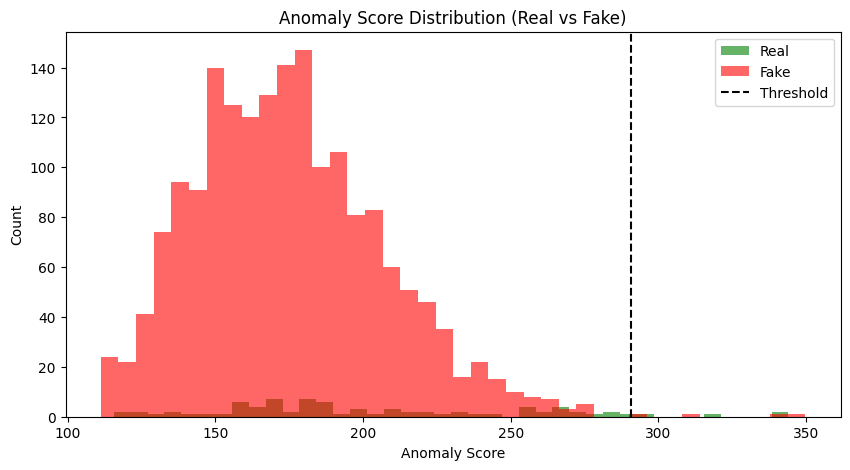

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(real_scores, bins=40, alpha=0.6, label="Real", color="green")
plt.hist(fake_scores, bins=40, alpha=0.6, label="Fake", color="red")
plt.axvline(threshold, color='black', linestyle='--', label="Threshold")
plt.legend()
plt.title("Anomaly Score Distribution (Real vs Fake)")
plt.xlabel("Anomaly Score")
plt.ylabel("Count")
plt.show()


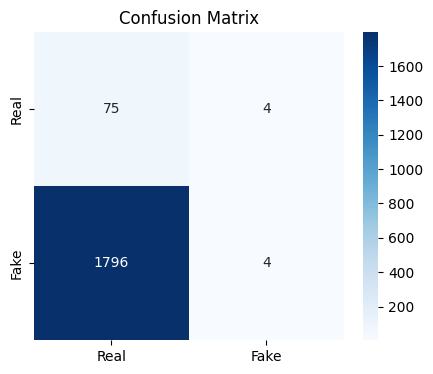

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

true_labels = [0]*len(real_scores) + [1]*len(fake_scores)
pred_labels = [0 if s < threshold else 1 for s in real_scores] + \
              [1 if s > threshold else 0 for s in fake_scores]

cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Real", "Fake"],
            yticklabels=["Real", "Fake"],
            cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, ConcatDataset


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
REAL_DIR = "/content/drive/MyDrive/dataset/real_images"
FAKE_DIR = "/content/drive/MyDrive/dataset/fake_images"

print("Real images:", len(os.listdir(REAL_DIR)))
print("Fake images:", len(os.listdir(FAKE_DIR)))


Real images: 5012
Fake images: 1800


In [ ]:
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

class FaceDataset(Dataset):
    def __init__(self, folder, transform=None):
        self.paths = [os.path.join(folder, f)
                      for f in os.listdir(folder)
                      if f.lower().endswith(("jpg","png","jpeg"))]
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        if self.transform: img = self.transform(img)
        return img

real_ds = FaceDataset(REAL_DIR, transform)
fake_ds = FaceDataset(FAKE_DIR, transform)

# Combine both into a single training dataset
combined_ds = ConcatDataset([real_ds, fake_ds])
combined_loader = DataLoader(combined_ds, batch_size=64, shuffle=True)

# Evaluation loaders stay separate
real_loader = DataLoader(real_ds, batch_size=1, shuffle=False)
fake_loader = DataLoader(fake_ds, batch_size=1, shuffle=False)

len(real_ds), len(fake_ds), len(combined_ds)


NameError: name 'REAL_DIR' is not defined

In [ ]:
class BetaVAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.ReLU(),
            nn.Flatten()
        )

        self.fc_mu = nn.Linear(128 * 8 * 8, latent_dim)
        self.fc_logvar = nn.Linear(128 * 8 * 8, latent_dim)

        self.fc_dec = nn.Linear(latent_dim, 128 * 8 * 8)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1), nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparam(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.fc_dec(z)
        h = h.view(-1, 128, 8, 8)
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparam(mu, logvar)
        x_hat = self.decode(z)
        return x_hat, mu, logvar


In [ ]:
beta = 4  # stronger KL = better for detection

def beta_vae_loss(x, x_hat, mu, logvar):
    mse = F.mse_loss(x_hat, x, reduction="sum")
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return mse + beta * kl, mse, kl


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
vae = BetaVAE().to(device)

In [ ]:

vae = BetaVAE().to(device)
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)

EPOCHS = 50
PATIENCE = 4
best_loss = float("inf")
pat = 0

print("Training β-VAE on BOTH real + fake images...")

for epoch in range(EPOCHS):
    total = 0
    vae.train()

    for batch_i, imgs in enumerate(combined_loader):
        imgs = imgs.to(device)
        optimizer.zero_grad()

        x_hat, mu, logvar = vae(imgs)
        loss, mse, kl = beta_vae_loss(imgs, x_hat, mu, logvar)

        loss.backward()
        optimizer.step()
        total += loss.item()

        if batch_i % 10 == 0:
            print(f"Epoch {epoch+1}/{EPOCHS} | Batch {batch_i}/{len(combined_loader)} | Loss: {loss.item():.2f}")

    avg = total / len(combined_loader)
    print(f"\nEpoch {epoch+1} | Avg Loss = {avg:.2f}")

    if avg < best_loss - 0.5:
        best_loss = avg
        pat = 0
        torch.save(vae.state_dict(), "/content/drive/MyDrive/beta_vae_both.pth")
        print(f"Saved Best Model! Loss improved to {best_loss:.2f}\n")
    else:
        pat += 1
        print(f"No improvement. Patience: {pat}/{PATIENCE}")

    if pat >= PATIENCE:
        print("Early Stopping Triggered")
        break


Training β-VAE on BOTH real + fake images...


KeyboardInterrupt: 

In [ ]:
vae.load_state_dict(torch.load("/content/beta_vae_both.pth"))
vae.eval()


BetaVAE(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Flatten(start_dim=1, end_dim=-1)
  )
  (fc_mu): Linear(in_features=8192, out_features=128, bias=True)
  (fc_logvar): Linear(in_features=8192, out_features=128, bias=True)
  (fc_dec): Linear(in_features=128, out_features=8192, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(32, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): Sigmoid()
  )
)

new cell

In [ ]:
def get_scores(loader, label):
    scores, labels = [], []

    with torch.no_grad():
        for imgs in loader:
            imgs = imgs.to(device)
            x_hat, _, _ = vae(imgs)

            mse = F.mse_loss(x_hat, imgs, reduction="none")
            mse = mse.view(mse.size(0), -1).mean(dim=1)

            scores.extend(mse.cpu().numpy())
            labels.extend([label] * len(mse))

    return np.array(scores), np.array(labels)

real_scores, real_labels = get_scores(real_loader, 0)
fake_scores, fake_labels = get_scores(fake_loader, 1)

scores = np.concatenate([real_scores, fake_scores])
labels = np.concatenate([real_labels, fake_labels])


KeyboardInterrupt: 

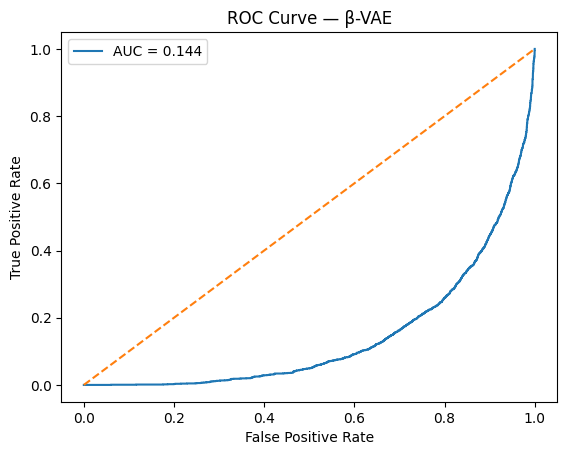

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(labels, scores)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — β-VAE")
plt.legend()
plt.show()


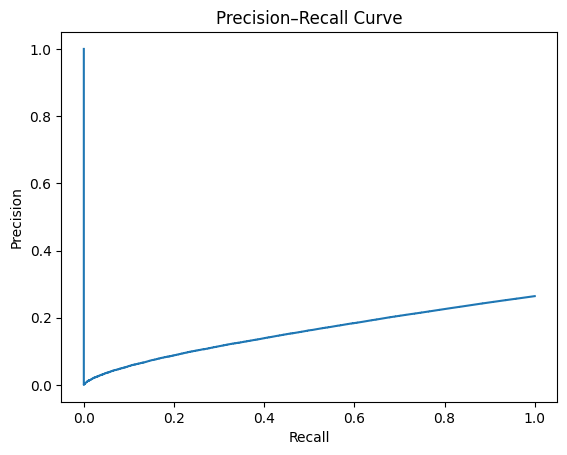

In [ ]:
from sklearn.metrics import precision_recall_curve
precision, recall, _ = precision_recall_curve(labels, scores)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.show()


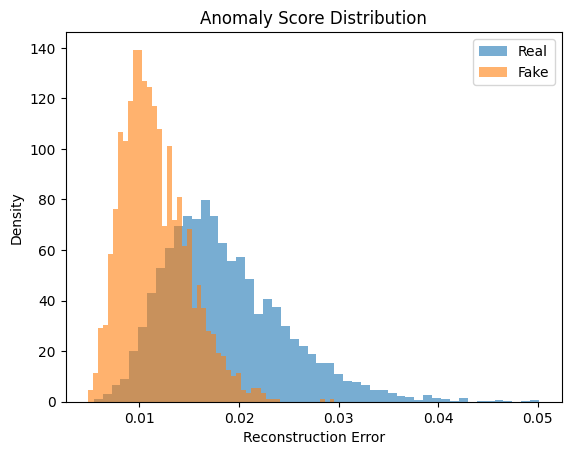

In [ ]:
plt.figure()
plt.hist(real_scores, bins=50, alpha=0.6, label="Real", density=True)
plt.hist(fake_scores, bins=50, alpha=0.6, label="Fake", density=True)
plt.xlabel("Reconstruction Error")
plt.ylabel("Density")
plt.title("Anomaly Score Distribution")
plt.legend()
plt.show()


In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve,
    confusion_matrix,
    f1_score
)


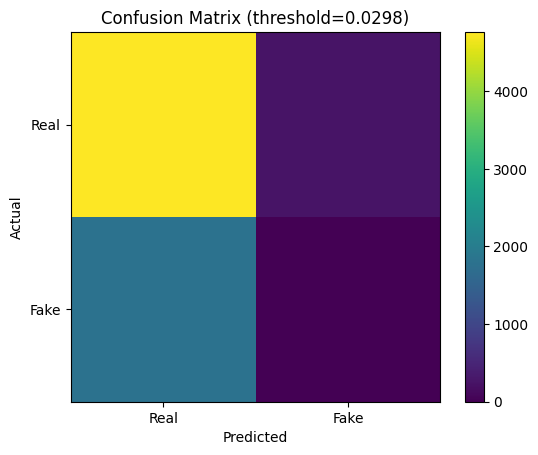

In [ ]:
threshold = np.percentile(real_scores, 95)

preds = (scores > threshold).astype(int)
cm = confusion_matrix(labels, preds)

plt.figure()
plt.imshow(cm)
plt.colorbar()
plt.xticks([0,1], ["Real", "Fake"])
plt.yticks([0,1], ["Real", "Fake"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix (threshold={threshold:.4f})")
plt.show()


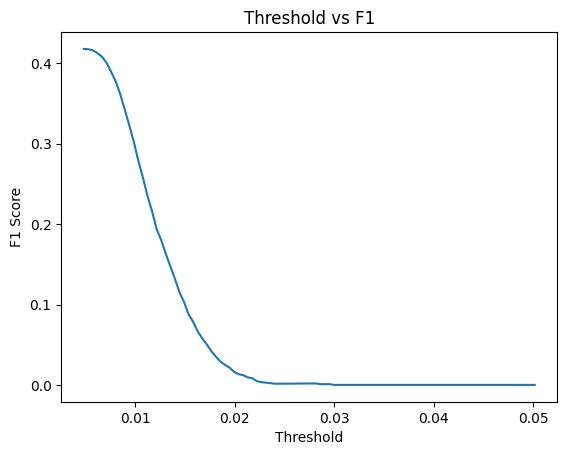

In [ ]:
from sklearn.metrics import f1_score

ths = np.linspace(scores.min(), scores.max(), 100)
f1s = []

for t in ths:
    preds = (scores > t).astype(int)
    f1s.append(f1_score(labels, preds))

plt.figure()
plt.plot(ths, f1s)
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("Threshold vs F1")
plt.show()


new cells end

In [ ]:
def anomaly_score(img):
    img = img.unsqueeze(0).to(device)
    with torch.no_grad():
        _, mu, logvar = vae(img)
        kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()).item()
    return kl


In [ ]:
real_scores = [anomaly_score(img[0]) for img in real_loader]
fake_scores = [anomaly_score(img[0]) for img in fake_loader]

len(real_scores), len(fake_scores)


KeyboardInterrupt: 

In [ ]:
threshold = np.percentile(real_scores, 95)
print("Threshold:", threshold)

real_pred = ["real" if s < threshold else "fake" for s in real_scores]
fake_pred = ["fake" if s > threshold else "real" for s in fake_scores]

real_acc = sum(p=="real" for p in real_pred) / len(real_pred)
fake_acc = sum(p=="fake" for p in fake_pred) / len(fake_pred)
overall = (real_acc + fake_acc) / 2

print("Real Accuracy:", real_acc)
print("Fake Accuracy:", fake_acc)
print("Overall Accuracy:", overall)


In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

plt.figure(figsize=(10,5))
plt.hist(real_scores, bins=40, alpha=0.6, label="Real")
plt.hist(fake_scores, bins=40, alpha=0.6, label="Fake")
plt.axvline(threshold, color='black', linestyle='--')
plt.legend()
plt.title("KL Divergence Scores (Real vs Fake)")
plt.show()

# Confusion matrix
true_labels = [0]*len(real_scores) + [1]*len(fake_scores)
pred_labels = [0 if s < threshold else 1 for s in real_scores] + \
              [1 if s > threshold else 0 for s in fake_scores]

cm = confusion_matrix(true_labels, pred_labels)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.show()

# ROC Curve
scores = real_scores + fake_scores
fpr, tpr, _ = roc_curve(true_labels, scores)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.title("ROC Curve")
plt.show()


In [ ]:
def get_latent(img):
    img = img.unsqueeze(0).to(device)
    with torch.no_grad():
        _, mu, logvar = vae(img)
    return mu.cpu().numpy().flatten()


In [ ]:
import numpy as np

X = []
y = []  # 0 = real, 1 = fake

# Extract real image latent vectors
for img in real_loader:
    latent = get_latent(img[0])
    X.append(latent)
    y.append(0)

# Extract fake image latent vectors
for img in fake_loader:
    latent = get_latent(img[0])
    X.append(latent)
    y.append(1)

X = np.array(X)
y = np.array(y)

print("Latent shape:", X.shape)
print("Labels shape:", y.shape)

Latent shape: (6812, 128)
Labels shape: (6812,)


In [ ]:
print(X[0].shape)

(128,)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# train–test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# classifier
clf = LogisticRegression(max_iter=5000)
clf.fit(X_train, y_train)

# predictions
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:,1]

# evaluation
print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1003
           1       0.94      0.93      0.93       360

    accuracy                           0.97      1363
   macro avg       0.96      0.96      0.96      1363
weighted avg       0.97      0.97      0.97      1363

AUC: 0.992918466821757
Confusion Matrix:
 [[980  23]
 [ 24 336]]


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

clf = LogisticRegression(max_iter=5000)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))


              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1003
           1       0.94      0.96      0.95       360

    accuracy                           0.97      1363
   macro avg       0.96      0.97      0.97      1363
weighted avg       0.97      0.97      0.97      1363

AUC: 0.9957904065581035


In [ ]:
import pickle
import torch

# Save VAE
torch.save(vae.state_dict(), "vae_ffhq.pth")
print("Saved: vae_ffhq.pth")

# Save classifier
with open("latent_classifier.pkl", "wb") as f:
    pickle.dump(clf, f)
print("Saved: latent_classifier.pkl")

# Save scaler
with open("latent_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
print("Saved: latent_scaler.pkl")


Saved: vae_ffhq.pth
Saved: latent_classifier.pkl
Saved: latent_scaler.pkl


In [ ]:
import torch
import torch.nn as nn

class BetaVAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.ReLU(),
            nn.Flatten()
        )

        self.fc_mu = nn.Linear(128 * 8 * 8, latent_dim)
        self.fc_logvar = nn.Linear(128 * 8 * 8, latent_dim)

        self.fc_dec = nn.Linear(latent_dim, 128 * 8 * 8)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1), nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparam(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.fc_dec(z)
        h = h.view(-1, 128, 8, 8)
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparam(mu, logvar)
        x_hat = self.decode(z)
        return x_hat, mu, logvar


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

vae = BetaVAE(latent_dim=128).to(device)
vae.load_state_dict(torch.load("/content/beta_vae_both.pth", map_location=device))
vae.eval()

print("Loaded BetaVAE successfully!")


Loaded BetaVAE successfully!


In [ ]:
from PIL import Image
import torch
import numpy as np
import pickle
from torchvision import transforms

device = "cuda" if torch.cuda.is_available() else "cpu"

# Load beta-VAE
vae = BetaVAE(latent_dim=128).to(device)
vae.load_state_dict(torch.load("/content/beta_vae_both.pth", map_location=device))
vae.eval()

# Load classifier & scaler
with open("latent_classifier.pkl", "rb") as f:
    clf = pickle.load(f)

with open("latent_scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

def predict_image(path):
    img = Image.open(path).convert("RGB")
    img = transform(img).unsqueeze(0).to(device)

    # ------- FIX HERE: use VAE.encode ----------
    with torch.no_grad():
        mu, logvar = vae.encode(img)
        latent = mu.cpu().numpy()   # only mu is used for classification

    latent_scaled = scaler.transform(latent)
    pred = clf.predict(latent_scaled)[0]
    prob = clf.predict_proba(latent_scaled)[0][1]

    label = "FAKE" if pred == 1 else "REAL"
    return label, float(prob)

# Test example
label, conf = predict_image("/content/Gemini_Generated_Image_wr28hqwr28hqwr28.png")
print("Prediction:", label)
print("Confidence:", conf)


Prediction: FAKE
Confidence: 0.8523390878194084


In [ ]:
import os

folder = "/content/drive/MyDrive/dataset/500_real_val_images"

for f in os.listdir(folder):
    if f.startswith("._") or f.endswith(".DS_Store"):
        os.remove(os.path.join(folder, f))
        print("Removed:", f)

Removed: ._05314.png
Removed: ._05328.png
Removed: ._05472.png
Removed: ._05300.png
Removed: ._05062.png
Removed: ._05089.png
Removed: ._05301.png
Removed: ._05466.png
Removed: ._05499.png
Removed: ._05467.png
Removed: ._05076.png
Removed: ._05274.png
Removed: ._05248.png
Removed: ._05102.png
Removed: ._05260.png
Removed: ._05116.png
Removed: ._05289.png
Removed: ._05129.png
Removed: ._05470.png
Removed: ._05101.png
Removed: ._05261.png
Removed: ._05103.png
Removed: ._05088.png
Removed: ._05471.png
Removed: ._05498.png
Removed: ._05074.png
Removed: ._05315.png
Removed: ._05048.png
Removed: ._05063.png
Removed: ._05317.png
Removed: ._05249.png
Removed: ._05075.png
Removed: ._05500.png
Removed: ._05465.png
Removed: ._05049.png
Removed: ._05277.png
Removed: ._05128.png
Removed: ._05276.png
Removed: ._05458.png
Removed: ._05275.png
Removed: ._05329.png
Removed: ._05473.png
Removed: ._05459.png
Removed: ._05100.png
Removed: ._05302.png
Removed: ._05117.png
Removed: ._05077.png
Removed: ._05

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import shutil
from PIL import Image
import torch
import pickle
from torchvision import transforms

In [ ]:
import os
import shutil
from PIL import Image
import torch
import pickle
from torchvision import transforms

# -------------------------------
# Load Models
# -------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"

vae = BetaVAE(latent_dim=128).to(device)
vae.load_state_dict(torch.load("/content/beta_vae_both.pth", map_location=device))
vae.eval()

with open("latent_classifier.pkl", "rb") as f:
    clf = pickle.load(f)

with open("latent_scaler.pkl", "rb") as f:
    scaler = pickle.load(f)


# -------------------------------
# Paths (CHANGE THESE TO YOUR PATHS)
# -------------------------------
REAL_VAL = "/content/drive/MyDrive/pattern_project/chatgpt/chatgpt"
FAKE_VAL = "/content/drive/MyDrive/pattern_project/gemini/gemini"

OUT_REAL = "/content/drive/MyDrive/pattern_project/predicted_real"
OUT_FAKE = "/content/drive/MyDrive/pattern_project/predicted_fake"

# 🔥 FIX: ensure folders exist
os.makedirs(OUT_REAL, exist_ok=True)
os.makedirs(OUT_FAKE, exist_ok=True)

print("Output folders ready:", OUT_REAL, OUT_FAKE)


# -------------------------------
# Preprocessing
# -------------------------------
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])


# -------------------------------
# Prediction function
# -------------------------------
def predict_single(path):
    img = Image.open(path).convert("RGB")
    img = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        mu, logvar = vae.encode(img)
        latent = mu.cpu().numpy()

    latent_scaled = scaler.transform(latent)
    pred = clf.predict(latent_scaled)[0]

    label = "FAKE" if pred == 1 else "REAL"
    return label


# -------------------------------
# Batch prediction + folder move
# -------------------------------
def classify_and_sort(folder):
    for fname in os.listdir(folder):
        if not fname.lower().endswith((".jpg", ".png", ".jpeg")):
            continue

        src_path = os.path.join(folder, fname)

        label = predict_single(src_path)

        # ----- FIXED PATHS -----
        if label == "REAL":
            dst_path = os.path.join(OUT_REAL, fname)
        else:
            dst_path = os.path.join(OUT_FAKE, fname)

        # 🔥 GUARANTEED SAFE COPY
        shutil.copy2(src_path, dst_path)

        print(f"{fname} → {label}")


# -------------------------------
# Run for both folders
# -------------------------------
print("\nProcessing Fake validation images...")
classify_and_sort(REAL_VAL)

print("\nProcessing FAKE validation images...")
classify_and_sort(FAKE_VAL)

print("\nDONE — Files moved into:")
print("  →", OUT_REAL)
print("  →", OUT_FAKE)


Output folders ready: /content/drive/MyDrive/pattern_project/predicted_real /content/drive/MyDrive/pattern_project/predicted_fake

Processing Fake validation images...
ChatGPT Image Dec 17, 2025, 12_16_35 AM.png → FAKE
ChatGPT Image Dec 17, 2025, 12_17_48 AM.png → FAKE
ChatGPT Image Dec 17, 2025, 12_19_43 AM (1).png → REAL
ChatGPT Image Dec 17, 2025, 12_19_43 AM.png → REAL
ChatGPT Image Dec 17, 2025, 12_20_04 AM.png → FAKE
ChatGPT Image Dec 17, 2025, 12_20_53 AM.png → REAL
ChatGPT Image Dec 17, 2025, 12_22_01 AM.png → FAKE
ChatGPT Image Dec 17, 2025, 12_23_30 AM.png → FAKE

Processing FAKE validation images...
Gemini_Generated_Image_d5hybwd5hybwd5hy.png → REAL
Gemini_Generated_Image_k9p35fk9p35fk9p3.png → FAKE
Gemini_Generated_Image_qn6pvqqn6pvqqn6p.png → FAKE
Gemini_Generated_Image_ty6ejqty6ejqty6e.png → FAKE
Gemini_Generated_Image_wq3z54wq3z54wq3z.png → FAKE
Gemini_Generated_Image_z5sssrz5sssrz5ss.png → FAKE

DONE — Files moved into:
  → /content/drive/MyDrive/pattern_project/predict

In [ ]:

from sklearn.manifold import TSNE

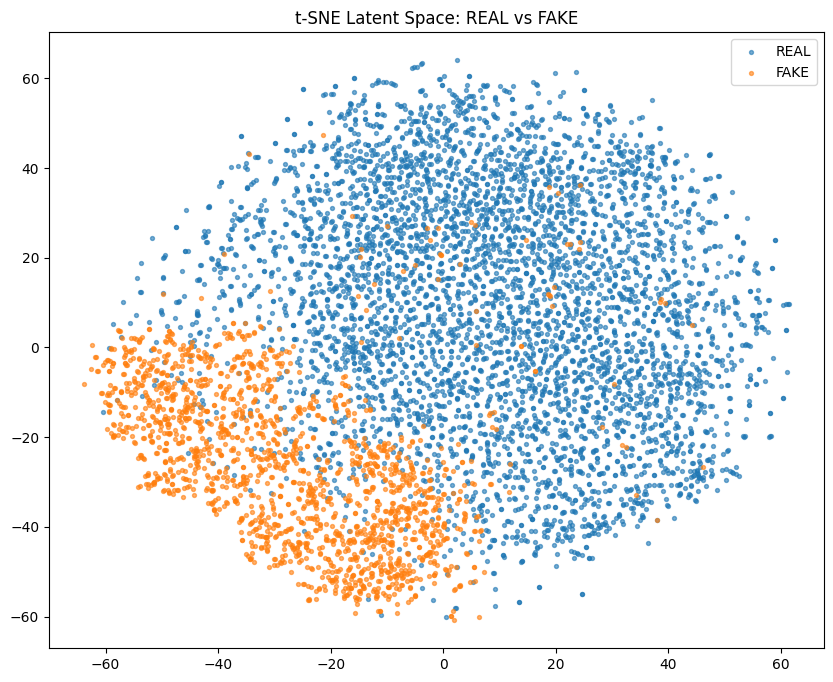

In [ ]:
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(10, 8))
plt.scatter(X_tsne[y==0,0], X_tsne[y==0,1], s=8, label="REAL", alpha=0.6)
plt.scatter(X_tsne[y==1,0], X_tsne[y==1,1], s=8, label="FAKE", alpha=0.6)
plt.legend()
plt.title("t-SNE Latent Space: REAL vs FAKE")
plt.show()


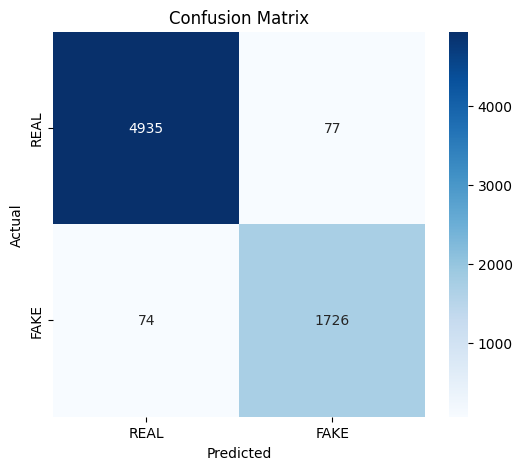

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
y_pred = clf.predict(scaler.transform(X))

cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["REAL","FAKE"],
            yticklabels=["REAL","FAKE"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



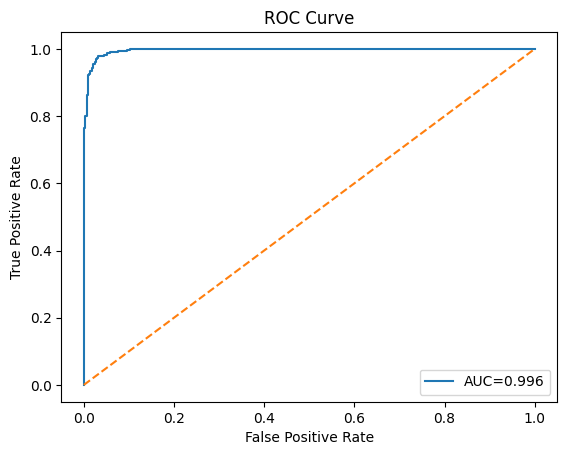

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/pattern_project/gemini.zip"
extract_path = "/content/drive/MyDrive/pattern_project/gemini"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
